Notebook 02: Exploratory Data Analysis

Objective: This notebook explores patterns in the cleaned video game sales dataset. The analysis focuses on sales distributions, release trends, genre performance, platform performance, publisher performance, and regional market differences.

The purpose of this stage is to identify meaningful patterns and refine the questions that will be investigated in later statistical and machine-learning notebooks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
processed_file_path = Path("../data/processed/video_game_sales_cleaned.csv")

df = pd.read_csv(processed_file_path)

df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (16287, 19)

Data types:
name                        str
platform                    str
year                      int64
genre                       str
publisher                   str
na_sales                float64
eu_sales                float64
jp_sales                float64
other_sales             float64
global_sales            float64
regional_sales_total    float64
decade                      str
sales_tier                  str
is_high_seller            int64
na_sales_share          float64
eu_sales_share          float64
jp_sales_share          float64
other_sales_share       float64
dominant_region             str
dtype: object


In [5]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


How are global video game sales distributed

In [6]:
df["global_sales"].describe()

count    16287.000000
mean         0.541022
std          1.567520
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: global_sales, dtype: float64

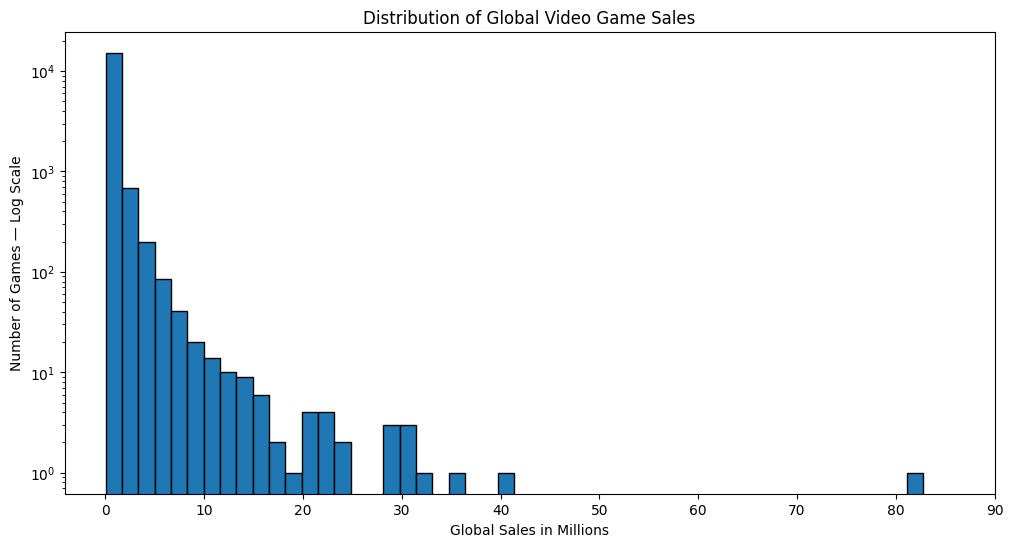

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df["global_sales"],
    bins=50,
    edgecolor="black"
)

ax.set_yscale("log")

ax.set_title("Distribution of Global Video Game Sales")
ax.set_xlabel("Global Sales in Millions")
ax.set_ylabel("Number of Games — Log Scale")

ax.set_xticks(range(0, 91, 10))

plt.show()

Interpretation

Global video game sales are strongly right-skewed. Most games sold relatively few copies, while progressively fewer games reached higher sales levels. The logarithmic y-axis makes the rare high-selling titles visible without removing them from the dataset. Only a small number of games sold more than 20 million copies, and one extreme title exceeded 80 million copies.

How many games fall into each sales-performance category?

In [8]:
sales_tier_order = [
    "low",
    "medium",
    "high",
    "blockbuster"
]

sales_tier_counts = (
    df["sales_tier"]
    .value_counts()
    .reindex(sales_tier_order)
)

sales_tier_counts

sales_tier
low            12327
medium          1902
high            1852
blockbuster      206
Name: count, dtype: int64

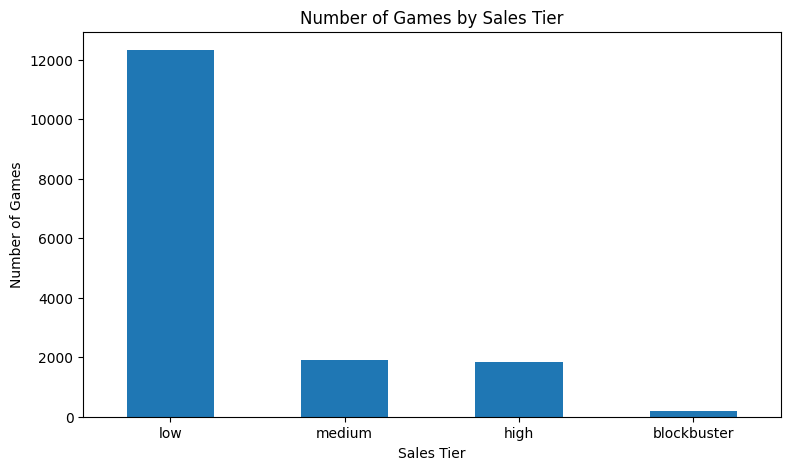

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

sales_tier_counts.plot(kind="bar", ax=ax)

ax.set_title("Number of Games by Sales Tier")
ax.set_xlabel("Sales Tier")
ax.set_ylabel("Number of Games")
ax.tick_params(axis="x", rotation=0)

plt.show()

In [10]:
sales_tier_percentages = (
    df["sales_tier"]
    .value_counts(normalize=True)
    .reindex(sales_tier_order)
    .mul(100)
    .round(2)
)

sales_tier_percentages

sales_tier
low            75.69
medium         11.68
high           11.37
blockbuster     1.26
Name: proportion, dtype: float64

Interpretation

The sales-tier distribution is highly uneven. Approximately **75.69%** of games fall into the low sales tier, compared with **11.68%** in the medium tier, **11.37%** in the high tier, and only **1.26%** in the blockbuster tier.

This shows that major commercial success is relatively uncommon, while most games generate comparatively low global sales.

This imbalance is important for the later `is_high_seller` classification task. Model performance should therefore be evaluated using precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

How did the number of video game releases change over time?

In [11]:
games_by_year = (
    df.groupby("year")
    .size()
    .reset_index(name="game_count")
)

games_by_year.head()

,year,game_count
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14


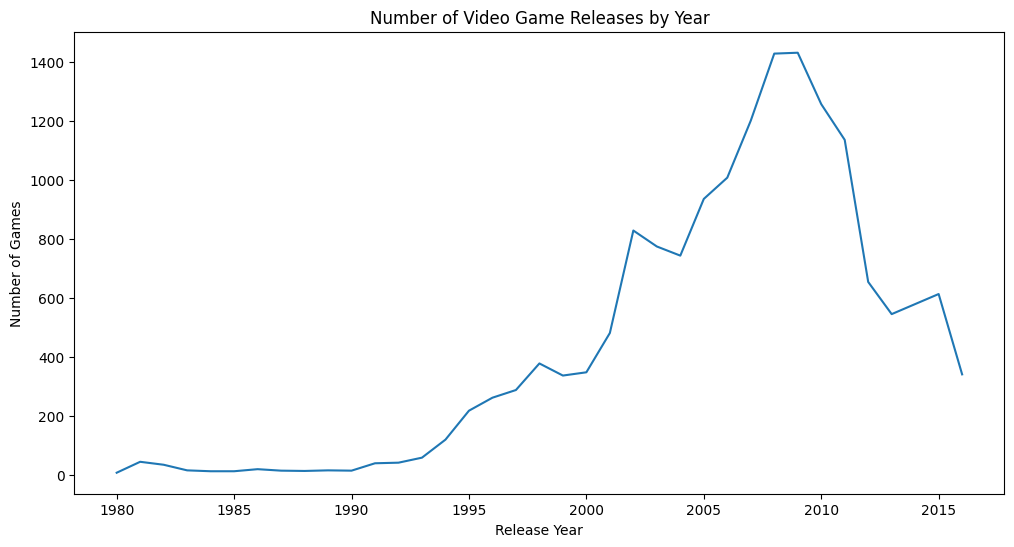

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    games_by_year["year"],
    games_by_year["game_count"]
)

ax.set_title("Number of Video Game Releases by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

plt.show()

In [13]:
games_by_decade = (
    df.groupby("decade")
    .size()
    .reset_index(name="game_count")
)

games_by_decade

,decade,game_count
0,1980s,205
1,1990s,1769
2,2000s,9183
3,2010s,5130


Interpretation

The number of video game releases remained relatively low throughout the 1980s and early 1990s. Releases began increasing more noticeably during the mid-to-late 1990s and grew rapidly throughout the 2000s.

The number of releases reached its highest level around 2008–2009, with more than 1,400 games released per year. After this peak, the number of recorded releases declined sharply.

The decline after 2011 should be interpreted cautiously because the dataset ends in 2016 and may not contain complete coverage for the most recent years. Therefore, the later drop may reflect both a real market change and limitations in the dataset.

How Did Video Game Sales Change over Time?

In [14]:
yearly_sales_summary = (
    df.groupby("year")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median")
    )
    .reset_index()
)

yearly_sales_summary.head()

,year,game_count,total_global_sales,average_global_sales,median_global_sales
0,1980,9,11.38,1.264444,0.770
1,1981,46,35.77,0.777609,0.465
2,1982,36,28.86,0.801667,0.540
3,1983,17,16.79,0.987647,0.770
4,1984,14,50.36,3.597143,1.485


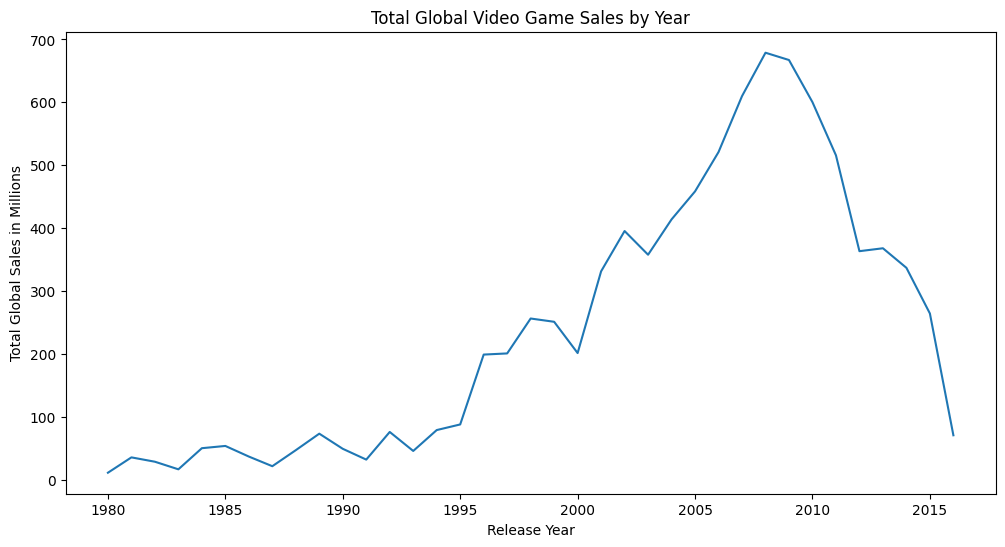

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["total_global_sales"]
)

ax.set_title("Total Global Video Game Sales by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Total Global Sales in Millions")

plt.show()

Interpretation

Total global video game sales remained relatively low throughout the 1980s and early 1990s before increasing more rapidly during the late 1990s and 2000s.

Sales reached their highest level around 2008, at approximately 680 million units, before declining in the following years. This overall pattern is similar to the trend in the number of games released, suggesting that years with more releases also tended to generate higher total sales.

However, total sales alone do not show how well the typical game performed because years with more releases naturally have more opportunities to accumulate sales. For this reason, average and median sales per game should also be examined.

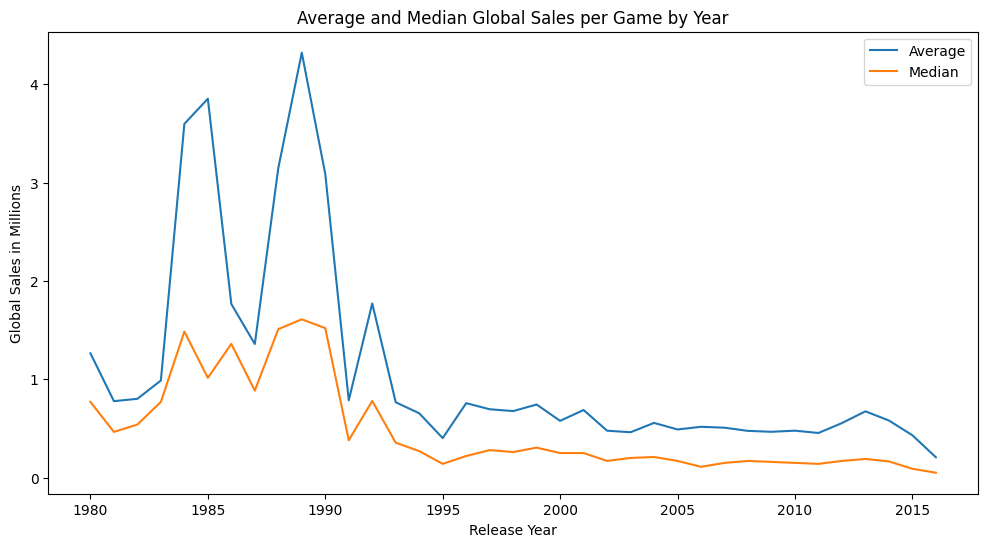

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["average_global_sales"],
    label="Average"
)

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["median_global_sales"],
    label="Median"
)

ax.set_title("Average and Median Global Sales per Game by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Global Sales in Millions")
ax.legend()

plt.show()

Interpretation

Average global sales were consistently higher than median global sales, indicating that a relatively small number of highly successful games pulled the yearly averages upward.

The gap was especially large during parts of the 1980s and early 1990s. These years also contained fewer releases, so individual blockbuster titles could have had a stronger influence on the yearly mean.

From the mid-1990s onward, both measures became lower and more stable. Although the industry released more games and generated higher total sales during much of the 2000s, the typical individual title continued to record relatively modest sales.

The median is a better measure of typical game performance, while the mean reflects the influence of unusually successful releases.

This section (below) compares genres using game count, total sales, typical sales performance, and the proportion of titles that became high sellers. Total sales alone may favour genres with more releases, so average, median, and high-seller rate are also considered.

In [17]:
genre_summary = (
    df.groupby("genre")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median"),
        high_seller_rate=("is_high_seller", "mean")
    )
    .reset_index()
)

genre_summary["high_seller_percentage"] = (
    genre_summary["high_seller_rate"] * 100
)

genre_summary

,genre,game_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate,high_seller_percentage
0,Action,3250,1722.83,0.530102,0.190,0.128923,12.892308
1,Adventure,1274,234.59,0.184137,0.060,0.031397,3.139717
2,Fighting,836,444.05,0.531160,0.210,0.147129,14.712919
3,Misc,1686,789.87,0.468488,0.160,0.099644,9.964413
4,Platform,875,829.13,0.947577,0.280,0.221714,22.171429
5,Puzzle,570,242.21,0.424930,0.105,0.098246,9.824561
6,Racing,1225,726.76,0.593273,0.190,0.147755,14.775510
7,Role-Playing,1468,923.79,0.629285,0.190,0.138283,13.828338
8,Shooter,1282,1026.20,0.800468,0.230,0.194228,19.422777
9,Simulation,847,389.69,0.460083,0.160,0.109799,10.979929


Number of games by genre

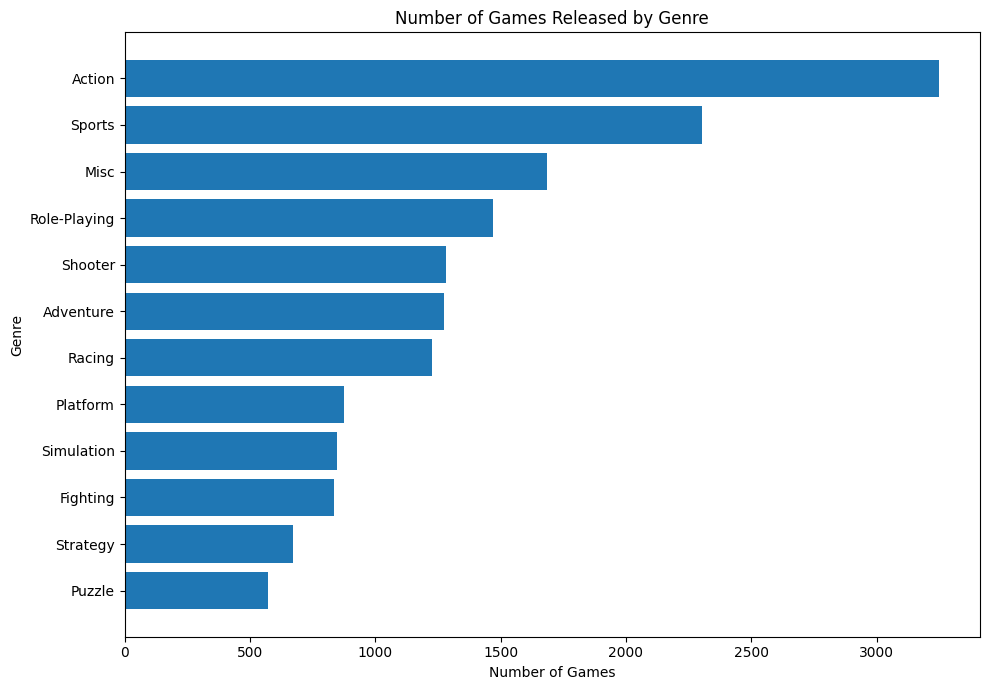

In [18]:
genre_game_count = genre_summary.sort_values(
    "game_count",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    genre_game_count["genre"],
    genre_game_count["game_count"]
)

ax.set_title("Number of Games Released by Genre")
ax.set_xlabel("Number of Games")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()